# GO proposal for Transients

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib notebook

In [2]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy.table import Table
from astropy.time import Time
from astropy import units as u
from astropy import constants as c
from astropy.coordinates import SkyCoord
from ipywidgets import *
from tqdm import tqdm
from pathlib import Path
from mpl_toolkits.axes_grid1 import make_axes_locatable

# PlatoSim libraries
# import platosim.smbhb     as bh
import platosim.slurm     as sm
import platosim.utilities as ut
import platosim.plot      as pt
import platosim.noise     as ns
import platosim.starquery as sq
from platosim.lightcurve   import LightCurve
from platosim.slurm        import workerOverview
from platosim.matplotlibrc import setup_notebook
setup_notebook()

from IPython.display import display, HTML
display(HTML("<style>.container {width:90% !important; }</style>"))

In preparation for Gaia DR4, the Gaia archive is in evolution. Unfortunately, it may be unstable at times and particular types of queries may time out. Please consider registering for a user account (https://www.cosmos.esa.int/web/gaia-users/register). For questions or advice, please contact the Gaia helpdesk (https://www.cosmos.esa.int/web/gaia/gaia-helpdesk).


In [3]:
# Paths to where data is stored
hdir = ut.getHomeDir('inputfiles/data_picsim')
path = ut.getWorkDir('smbhb')
idir = path / 'input'
ddir = path / 'data'
sdir = path / 'simulations'
gdir = path / 'godata'
fdir = Path('/lhome/nicholas/Nextcloud/latex/plato_go_proposals')
# fdir = path / 'figures'

In [4]:
# Load LOP catalogues for plotting
dc = pd.read_feather(hdir / 'PlatoGO_PIC210_LOPS2.ftr')
dn = pd.read_feather(f'{idir}/starcat_PlatoCS_QSO_LOPN1_targets.ftr')
ds = pd.read_feather(f'{idir}/starcat_PlatoCS_QSO_LOPS2_targets.ftr')
df = pd.concat([dn, ds])

---
## 0. Quick check of candidates
---

In [ ]:
# Checked:
# dx = pd.DataFrame({'ra': [186.4535958], 'dec': [33.5468611], 'mag': [10.11]}) # NGC 4395
# dx = pd.DataFrame({'ra': [187.0463250], 'dec': [44.0935583], 'mag': [9.64]})  # NGC 4449

In [5]:
# ra, dec, mag = 187.0463250, 44.0935583, 9.64
# # Create data frame
# dx = pd.DataFrame({'ra':[ra], 'dec':[dec], 'mag':[mag]})
# gal = SkyCoord(dx.ra, dx.dec, frame='icrs', unit=u.deg).galactic
# dx['l'] = gal.l.deg
# dx['b'] = gal.b.deg
# # Plot source in sky
# fig, ax = pt.plot_aitoff(dt, dx)
# # Plot source within LOPS2
# fig, ax = pt.plotPlatoFOV(
#     'LOPS2', system='galactic', ncamStars=True,
#     raStars=ra, decStars=dec, c=mag, 
#     clabel=r'$G$ [mag]', s=300, lw=0.5, ec='k',
#     figsize=(9,9)
# );
# # Cross-check with PIC catalogue

---
## 1. AGN with frequent flares
---

### Pictor A (ESO 252-18A)

Literature:
- [Smith+2023](https://iopscience.iop.org/article/10.3847/1538-4357/acff5c/pdf)

Technical notes:
- [CDS/DSS](https://portal.cds.unistra.fr/?target=Pictor%20A)
- N-CAM = 24
- Imagettes: YES (source extend 2-3 pixel)

In [322]:
# Download target from Simbad
df_PictorA = sq.simbadQuery('Pictor A', radius=15, maglim=19)

# Cross-match with LOPS2 sources
df_PictorA['gaiaDR3'] = [f'Gaia DR3 {i}' for i in df_PictorA.gaiaDR3]
ds_PictorA = dc[dc['gaiaDR3'].isin(df_PictorA['gaiaDR3'])].sort_values(by=['Pmag']).reset_index(drop=True)
ds_PictorA['ref'] = 'PictorA'
ds_PictorA

,PIC,gaiaDR3,ra,dec,Gmag,Pmag,PBmag,PRmag,ref
0,2699636000050,Gaia DR3 4799794011057558016,79.95718,-45.778848,16.842937,16.525375,16.887465,16.156663,PictorA


<IPython.core.display.Javascript object>


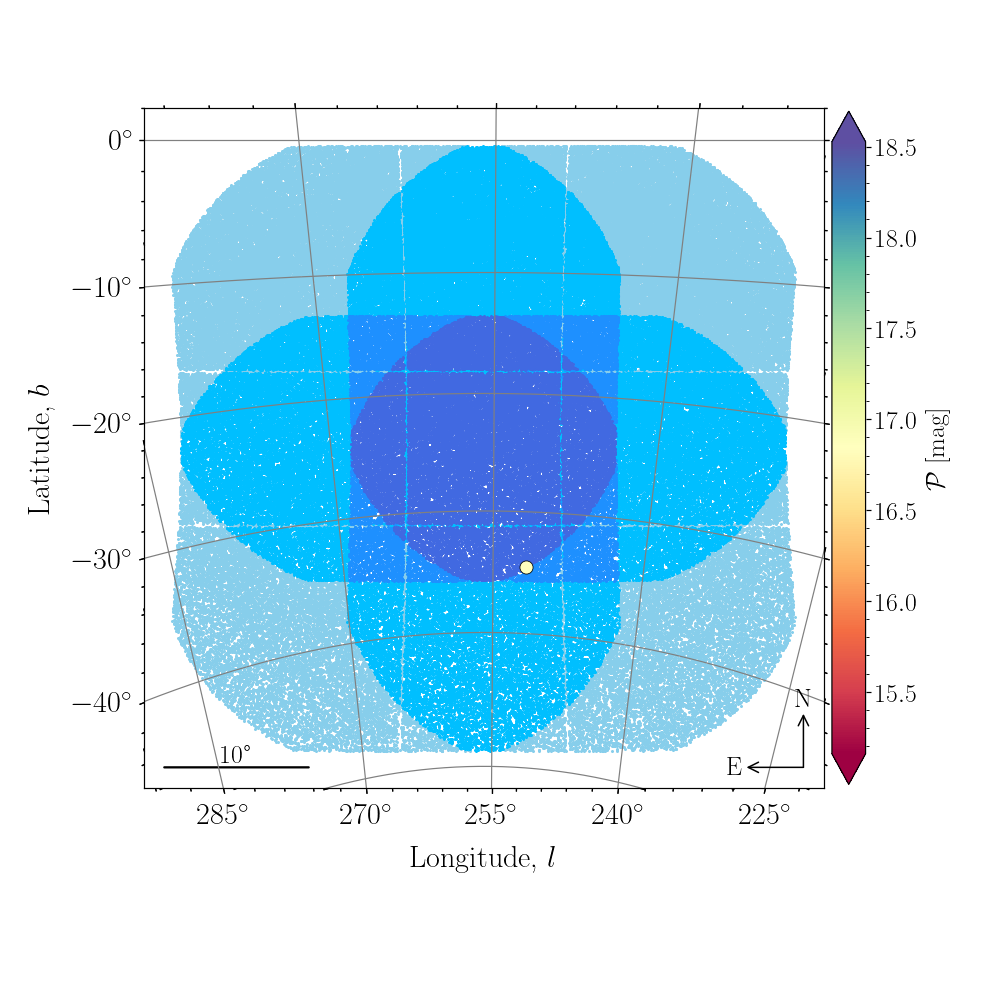

In [278]:
# Plot target in LOPS2 foorptint
dx = df_PictorA.copy()
fig, ax = pt.plotPlatoFOV(
    'LOPS2', system='galactic', ncamStars=True,
    raStars=dx.ra, decStars=dx.dec, c=dx.Gmag, 
    clabel=r'$\mathcal{P}$ [mag]', s=300, lw=0.5, ec='k',
    figsize=(9,9)
);

---
## 2. Tidal Disruption Events (TDEs)
---

---
## 3. Ambigous Nuclear TRansients (ANTs)
---

In [321]:
# Load Gaia DR3 IDs from Nada's catalogue
df_nuclear = pd.read_csv(ddir / 'flares_GaiaDR3_Ihanec2026.txt', names=['gaiaDR3'])
df_nuclear['gaiaDR3'] = [f'Gaia DR3 {i}' for i in df_nuclear.gaiaDR3]

# Cross-match with LOPS2 sources
ds_nuclear = dc[dc['gaiaDR3'].isin(df_nuclear['gaiaDR3'])].sort_values(by=['Pmag']).reset_index(drop=True)

# Remove too faint sources
ds_nuclear = ds_nuclear[ds_nuclear.Pmag < 18]
ds_nuclear['ref'] = 'nuclear'
ds_nuclear

,PIC,gaiaDR3,ra,dec,Gmag,Pmag,PBmag,PRmag,ref
0,3043339002435,Gaia DR3 4657632930055890048,85.431082,-69.244782,16.262539,16.313709,16.283694,16.357598,nuclear
1,3046927004386,Gaia DR3 4657598501602775808,85.313956,-69.613157,16.848726,16.899203,16.869577,16.942511,nuclear
2,3036898004520,Gaia DR3 4658472093632094848,82.401336,-68.538120,17.533257,17.435610,17.505331,17.342403,nuclear
3,2948282000199,Gaia DR3 5287186311395897344,107.107878,-60.929745,18.215025,17.894966,18.281312,17.508163,nuclear
4,2575788000061,Gaia DR3 4814204755910768896,75.166451,-39.583971,18.061357,17.931204,18.027641,17.805252,nuclear
5,3067219000251,Gaia DR3 5221999874758301696,133.799040,-71.818459,18.311546,17.998847,18.365770,17.625423,nuclear


<IPython.core.display.Javascript object>


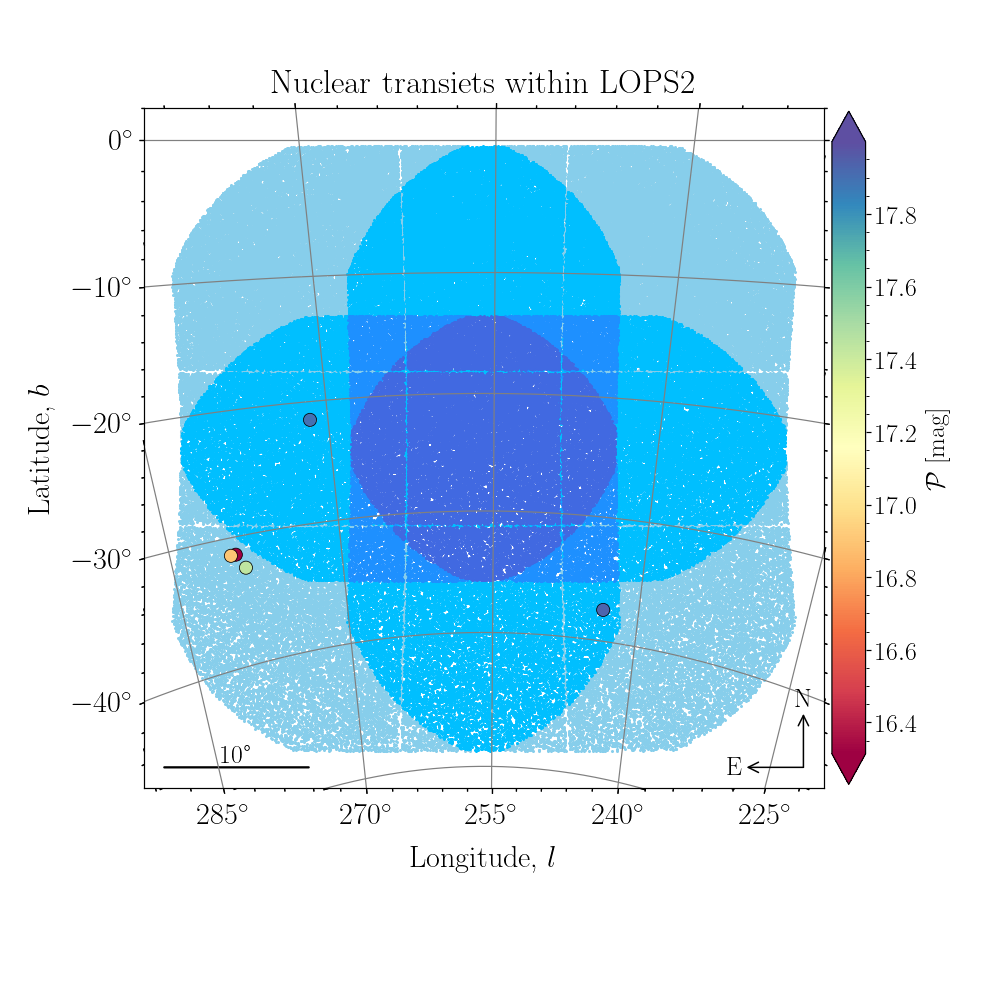

In [283]:
# Plot targets within LOPS2 foorptint
dx = ds2.copy()
fig, ax = pt.plotPlatoFOV(
    'LOPS2', system='galactic', ncamStars=True,
    raStars=dx.ra, decStars=dx.dec, c=dx.Pmag, 
    clabel=r'$\mathcal{P}$ [mag]', s=300, lw=0.5, ec='k',
    title='Nuclear transiets within LOPS2',
    figsize=(9,9)
);

In [ ]:
# dx0 = pd.read_csv(ddir / 'targets-2026-05-07-163913349840.csv')
# dx1 = pd.read_csv(ddir / 'targets-2026-05-07-164032825085.csv')
# dx2 = pd.read_csv(ddir / 'targets-2026-05-07-164042142138.csv')
# dx = pd.concat([dx0, dx1, dx2])
# dx

In [34]:
# # Find stars within the LOPS2
# df_match = dx[dx['GAIA_DR3_name'].isin(ds['gaiaDR3'])] #.sort_values(by=['Gmag'])
# df_match

In [35]:
# # Find stars within the LOPS2
# df_match = df[df['GAIA_DR3_name'].isin(ds['gaiaDR3'])] #.sort_values(by=['Gmag'])
# df_match.mag_last

In [284]:
# # Find stars within the LOPS2
# dn_match = df[df['GAIA_DR3_name'].isin(dn['gaiaDR3'])] #.sort_values(by=['Gmag'])
# dn_match

---
## 4. Bright and nearby galaxies
---

### Load Galaxies queried from Simbad

Sources:
- [Simbad criteria query](https://simbad.cds.unistra.fr/simbad/sim-fsam)
- [Simbad otype classes for AGN](https://simbad.cds.unistra.fr/guide/otypes.htx)
- [Gaia single-source search](https://gaia.ari.uni-heidelberg.de/singlesource.html)

We used the following Simbad query:
```
otype = 'G' & Vmag < 14   &
ra  >  46.5 & ra  < 144.5 & 
dec > -78.5 & dec < -17.5
```

<IPython.core.display.Javascript object>


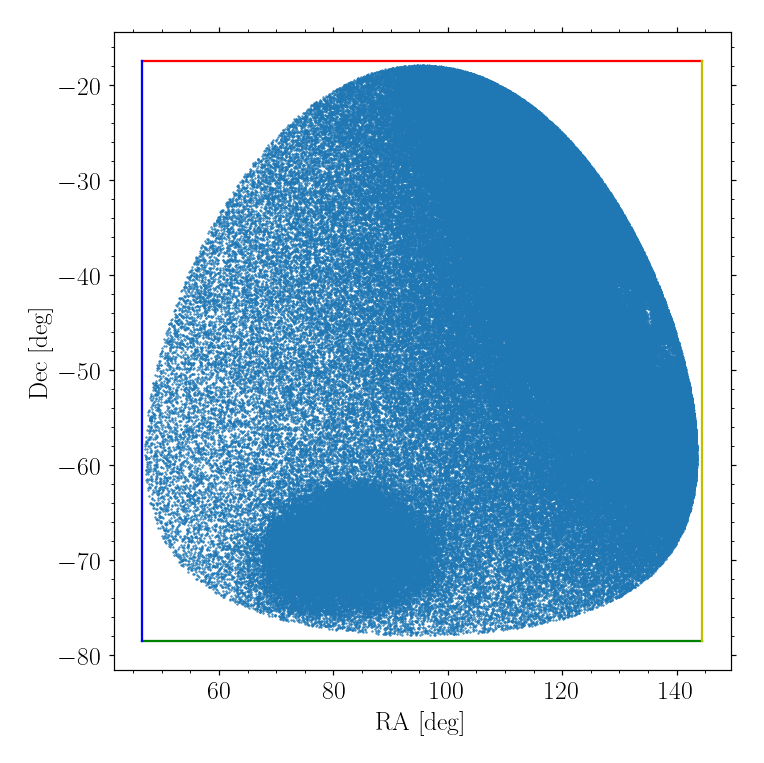

In [12]:
# Plot Simbad (RA, Dec) limits used
ra_min  = 46.5 
ra_max  = 144.5 
dec_min = -78.5 
dec_max = -17.5
dx = dc.copy().iloc[::100]
plt.figure(figsize=(7,7))
plt.plot(dx.ra, dx.dec, '.', ms=1)
plt.plot([ra_min, ra_max], [dec_min, dec_min], 'g-')
plt.plot([ra_min, ra_max], [dec_max, dec_max], 'r-')
plt.plot([ra_min, ra_min], [dec_min, dec_max], 'b-')
plt.plot([ra_max, ra_max], [dec_min, dec_max], 'y-')
plt.xlabel('RA [deg]')
plt.ylabel('Dec [deg]')
plt.tight_layout();

In [239]:
# Load the dataset from the Simbad query
df_gal = pd.read_csv(ddir / 'table_Simbad_Galaxy.csv')

# Change coordinates to deg
for i in range(df_gal.shape[0]):
    dx = df_gal.iloc[i]
    coor = SkyCoord(ra=dx.ra, dec=dx.dec,unit=(u.hourangle, u.deg))
    df_gal.ra.iloc[i]  = coor.ra.deg
    df_gal.dec.iloc[i] = coor.dec.deg

# Strip white-space from name column
df_gal.name = df_gal.name.str.strip()

#Sort values after magnitude
df_gal = df_gal.sort_values(by='Vmag').reset_index(drop=True)
df_gal
#--------------------------------------------
# otype = 'EmG'
# # print(df_gal.otype.unique())
# dx = df_gal[df_gal.otype == otype].reset_index(drop=True).iloc[0]
# print(dx['name'], dx.ra, dx.dec)
# fig, ax = pt.plotPlatoFOV(
#     'LOPS2', system='galactic', ncamStars=True, fovSize=30,
#     raStars=dx.ra, decStars=dx.dec, c=dx.Vmag, 
#     clabel=r'$\mathcal{P}$ [mag]', s=300, lw=0.5, ec='k',
#     figsize=(9,9));

,name,otype,ra,dec,Umag,Bmag,Vmag,Rmag,Imag
0,AM 0311-513,G,48.25,-51.3,,6.9,7.800000,,
1,NGC 1316,rG,50.674121,-37.2082,9.81,9.15,8.530000,7.66,
2,NGC 1269,EmG,49.327408,-41.10795,9.85,9.83,8.810000,8.72,
3,NGC 1553,GiP,64.043621,-55.780019,10.76,10.10,9.400000,8.74,
4,NGC 1365,Sy1,53.401908,-36.140658,10.48,10.08,9.630000,8.79,9.7
...,...,...,...,...,...,...,...,...,...
253,EC 04028-5412,AG?,61.005175,-54.064839,16.57,16.71,16.710000,,NaN
254,LEDA 74592,EmG,52.580279,-52.5183,,17.27,16.790000,16.45,
255,2MASX J03322988-2744244,EmG,53.124504,-27.740283,19.55,17.6891,16.891000,16.74,16.467
256,2MASX J03091681-4126222,EmG,47.319921,-41.439489,,17.8,16.900000,,


In [240]:
galaxies = [
    #---------- EmG
    6,  200, 'Gaia DR3 4682184230100236928', 'NGC 1543',                0.00391469862121995, # type -1.8
    6,  200, 'Gaia DR3 4682608675948630656', 'NGC 1533',                0.00264733319281051, # type -2.0
    12, 180, 'Gaia DR3 4778632260511770880', 'NGC 1546',                0.00427207436339927, # type -1.0
    12, 540, 'Gaia DR3 4779841276625379712', 'NGC 1515',                0.003922065898,      # type, 3.0, 2x5 imagettes
    12, 180, 'Gaia DR3 5267762579499072768', 'NGC 2434',                0.004683,            # ellip, E0-1
    12, 300, 'Gaia DR3 2886589765219489792', 'NGC 2188',                0.00248848233592635, #type=Sm
    6,  240, 'Gaia DR3 4827649760190224896', 'MCG-05-13-011',           0.00325454385120815, # type 8.0
    6,  120, 'Gaia DR3 4875289331278097920', 'NGC 1800',                0.00271957689871893, # type 9
    6,   40, 'Gaia DR3 4867469845100665984', 'LEDA 100592',             0.0597,              # spiral, S0
    6,  180, 'Gaia DR3 4682587304191364992', 'NGC 1536',                0.0043792785960588,  # spiral, SB(s)cpec?
    12, 100, 'Gaia DR3 2898562794012526976', 'MCG-05-15-009',           0.02236547258303609, # type -3.5
    12, 120, 'Gaia DR3 4780387905703181056', 'NGC 1522',                0.00303102055750614, # typeS0
    12, 150, 'Gaia DR3 2909444694948104960', 'MCG-05-15-002',           0.00463024864126015, # type 6.7
    6,   70, 'Gaia DR3 4657456114826746624', 'NGC 2150',                0.01501773163489739, # type 2.0
    12, 120, 'Gaia DR3 4779520318014377216', 'IC 2032',                 0.00356280714022338, # type 10, low surface brightness!
    6,   40, 'Gaia DR3 4651517996104218880', '2MASS J05144786-7210339', 0.02551098200075467, # Side-view
    6,   20, 'Gaia DR3 4657496728032368000', 'LEDA 3704836',            0.03720573917840188, # heavily contaminated
    6,   70, 'Gaia DR3 4682099400202230912', 'ESO 118-19',              0.00413285913950510, # type -1.0
    6,  120, 'Gaia DR3 4867020763319548416', 'LEDA 132286',             0.05965793842618949, # type Sc, RA/Dec offset -> nearby galaxy!
    #---------- G
    6,   30, 'Gaia DR3 4656785550168125056', 'GH 9-5',                  0,                   #  
    12,  30, 'Gaia DR3 4790403116604525440', 'LEDA 88351',              0.04706255819150727, # blob
    12,  35, 'Gaia DR3 5282816061921556352', '2MASX J06004328-6840104', 0.03844802039314166, # blob, SBb
    6,   30, 'Gaia DR3 5278637883389153920', '2MASX J06103555-7020514', 0.02627295517756778, # blob
    18,  50, 'Gaia DR3 4758875067354276992', '2MASX J05545691-6000478', 0.04993788069211535, # spiral, very bright nucleus
    6,   50, 'Gaia DR3 2908445376320359168', 'ESO 487-22',              0.00005580683032779, # spiral
    12,  50, 'Gaia DR3 4779756339354066432', 'LEDA 14406',              0.04455161645491246, # spiral, S0, bright nucleus
    24,  50, 'Gaia DR3 5495096680239697024', 'LEDA 148842',             0.03275932978941051, # spiral
    6,   40, 'Gaia DR3 4653143344889019648', 'GH 1-16',                 0,                   # spiral, SBb
    6,   30, 'Gaia DR3 4656903782037390208', 'GH 9-6',                  0,                   # spiral, Sc
    12,  30, 'Gaia DR3 4664234153020223616', 'GH 8-7',                  0,                   # spiral
    24,  25, 'Gaia DR3 4802112365684697088', 'LEDA 147930',             0.05177581885665716, # spiral
    6,   25, 'Gaia DR3 2908276154608140928', 'LEDA 3699613',            0.03522436845292485, # blob
    12,  35, 'Gaia DR3 4659042465275554560', 'GH 10-1',                 0,                   # spiral, Sb
    6,   20, 'Gaia DR3 4653907612830000640', 'GH 1-4',                  0,                   # blob
    6,   15, 'Gaia DR3 4663635438902448384', 'GH 7-19',                 0,                   # blob
    6,   50, 'Gaia DR3 4649824920004751360', 'ESO 33-3',                0.02551431764170665, # blob
    12,  15, 'Gaia DR3 4812006561584970496', '6dFGS gJ045614.0-423123', 0.00009071687046446, # blob, heavily contaminated!
    6,   20, 'Gaia DR3 4653920910048769280', 'GH 1-2',                  0,                   # blob 
    6,   30, 'Gaia DR3 4656919312639378048', 'GH 9-4',                  0,                   # spiral, Sb, side-view
    6,   20, 'Gaia DR3 4664205673099855744', 'GH 8-6',                  0,                   # blob
    6,   20, 'Gaia DR3 4664140080365377536', 'GH 8-10',                 0,                   # blob
    6,   20, 'Gaia DR3 4664166949679691648', 'GH 8-3',                  0,                   # blob
    6,   30, 'Gaia DR3 4653192277439350400', 'GH 1-8',                  0,                   # spiral, SBc
    6,   15, 'Gaia DR3 4663659318892318976', 'GH 7-15',                 0,                   # blob, crowded region!
    6,   20, 'Gaia DR3 4653176265803455360', 'GH 1-15',                 0,                   # blob, Sa
    6,   30, 'Gaia DR3 4656842587343485952', 'GH 9-2',                  0,                   # spiral, SBb, crowded region! 
    #---------- GiP
    12, 260, 'Gaia DR3 4778663149916408064', 'NGC 1553',                0.004026,            # type -3.0, 3x3 ima
    12, 300, 'Gaia DR3 4778669369028919808', 'NGC 1549',                0.004093,            # type -5.0, 3x3 ima
    12, 300, 'Gaia DR3 4776049297245581312', 'NGC 1617',                0.00355209498167741, # spiral, 1.0, 3x3 ima
    6,  260, 'Gaia DR3 4841932794190647680', 'NGC 1512',                0.00300659664811830, # spiral, 1.0, 3x3 ima
    12, 420, 'Gaia DR3 4779024098968883456', 'NGC 1596',                0.004983,            # type -2.0, 1x4 ima
    6,   80, 'Gaia DR3 4841557414048502528', 'NGC 1510',                0.00335461018899563, # spiral, S0, 1x1 ima
    12, 120, 'Gaia DR3 4779023205615002368', 'NGC 1602',                0.00524302880803428, # type 9.0, 1x1 ima
    12, 100, 'Gaia DR3 4779836088306553600', 'NGC 1515A',               0.04448529215646757, # spiral, 3.0, bar 
    #---------- GiG (mergers)
    6,  170, 'Gaia DR3 4676459725889776768', 'NGC 1559',                0.00433572548449467, # spiral, SB(s)cd, 2x2 ima
    12, 240, 'Gaia DR3 4778334769602793088', 'NGC 1574',                0.003439,            # type -2.5, 4x4 ima
    12, 140, 'Gaia DR3 4757235420651441280', 'NGC 1947',                0.003803,            # type -2.0, 2x2 ima
    12, 250, 'Gaia DR3 5506661240461437696', 'NGC 2427',                0.00326491815524199, # spiral, 8.0, faint, 6x4 ima
    6,  120, 'Gaia DR3 2919628436072070400', 'NGC 2272',                0.00710009953502366, # type -3.0, 2x2 ima
    6,  140, 'Gaia DR3 4761480944270070528', 'NGC 1796',                0.00338908352830591, # spiral, 6.0, 2x2 ima 
    6,   15, 'Gaia DR3 4661384734281674880', '2MASX J05073710-6822590', 0.01878966548251190, # faint, crowded region!
    12,  50, 'Gaia DR3 4774162230349105536', 'ESO 118-34',              0.00381524570791969, # type S0
    #---------- LSB
    6,  300, 'Gaia DR3 2959227076762704000', 'NGC 1744',                0.00247677853656447, # type 7.0, 2x4 ima    
    #---------- rG
    12,  60, 'Gaia DR3 4780599870929946496', 'IC 2082',                 0.0397,    
    24,  50, 'Gaia DR3 5501007689111963648', 'PKS 0620-526',            0.0497,
    #---------- SyG
    12, 460, 'Gaia DR3 4773934047325895168', 'NGC 1672',                0.004464,
    6,   18, 'Gaia DR3 2906862560611768960', 'LEDA 2824330',            0.068,
    #---------- Sy1
    12, 520, 'Gaia DR3 4779165759875235200', 'NGC 1566',                0.00473963,
    12,  14, 'Gaia DR3 4775331664045020160', 'LB 1727',                 0.10410067,
    12,  25, 'Gaia DR3 5282115196267296256', 'FRL 265',                 0.030451,
    6,   25, 'Gaia DR3 2936769208170781952', 'LEDA 3095733',            0.03778,
    12,  20, 'Gaia DR3 4789861813285837056', 'LEDA 3095692',            0.05145175,
    24,  30, 'Gaia DR3 2883688050953797760', 'IRAS 05563-3820',         0.03310493,
    12,  12, 'Gaia DR3 4756452052971526912', '2MASS J05522451-6402108', 0.680,
    6,   15, 'Gaia DR3 4879352885736712192', '2MASS J04432078-2820520', 0.15550,
    12,  50, 'Gaia DR3 5514459900347426432', 'ESO 209-12',              0.04007455,
    6,   14, 'Gaia DR3 4893164366689421696', 'LEDA 3095695',            0.08414478,
    6,   13, 'Gaia DR3 4879651849820703488', 'LEDA 75249',              0.28581,
    6,   13, 'Gaia DR3 4663169417750643712', '2MASX J04494090-6436213', 0.0600,
    6,   13, 'Gaia DR3 4837149952970309504', '2MASS J04124148-4712461', 0.132,
    12,  19, 'Gaia DR3 4780619627780461696', 'FRL 303',                 0.039,
    6,   14, 'Gaia DR3 4867236336317793536', 'CTS 49',                  0.181,
    6,   14, 'Gaia DR3 4881212744015331840', '2MASX J04470958-2657352', 0.113812,
    24,  17, 'Gaia DR3 5505467789310281472', 'LEDA 88588',              0.04057,
    18,  18, 'Gaia DR3 4799794011057558016', 'ESO 252-18A',             0.03497470,
    24,  23, 'Gaia DR3 4791851242137483392', 'IRAS 05562-5357',         0.0967,
    6,   18, 'Gaia DR3 4761465310590509056', 'LEDA 146811',             0.0053,
    #---------- Sy2
    6,  455, 'Gaia DR3 4823508724522473472', 'NGC 1808',                0.003343,
    12, 300, 'Gaia DR3 2899383923036427008', 'NGC 2217',                0.005425,
    6,   75, 'Gaia DR3 4825962731396079744', 'ESO 362-8',               0.0158,
    6,   30, 'Gaia DR3 4675802943784869248', '1RXS J042710.2-624712',   0.018,
    12,  50, 'Gaia DR3 4826515407787798400', 'MCG-05-13-017',           0.01246008,
    6,   65, 'Gaia DR3 5606511636595211392', 'MCG-05-18-002',           0.00565999979153,
    18,  60, 'Gaia DR3 5495804903167280256', '2MASX J06002140-5756210', 0.038150,
    12,  30, 'Gaia DR3 2892805751127673728', 'IRAS 06115-3241',         0.050018,
    6,   30, 'Gaia DR3 2957793279241779328', 'IRAS 05189-2524',         0.04089978,
    24,  75, 'Gaia DR3 4799082833193329152', 'ESO 253-3',               0.04210457,
    12,  60, 'Gaia DR3 4774591246042006016', 'ESO 119-8',               0.023260,
    18,  84, 'Gaia DR3 4805199897412245376', 'ESO 306-25',              0.025001,
    12,  90, 'Gaia DR3 4778481661779060480', 'ESO 157-23',              0.04392442,
    6,   25, 'Gaia DR3 4877062259417089664', 'MCG-05-13-003',           0.0380,
    12,  70, 'Gaia DR3 5481554579636887680', 'ESO 121-28',              0.04045890,
    24,  70, 'Gaia DR3 4799287514152123904', 'ESO 253-8',               0.035214,
    6,   60, 'Gaia DR3 4866483858047537280', 'LEDA 132310',             0.041993,
    12,  30, 'Gaia DR3 5283621321042741504', '2MASX J06291339-6630029', 0.046799,
    6,   60, 'Gaia DR3 4866264986514287232', 'ESO 304-11',              0.040895,
    #---------- LIN
    6,  420, 'Gaia DR3 5267697094131487488', 'NGC 2442',                0.004846,
    6,  130, 'Gaia DR3 4788661249667522816', 'ESO 202-23',              0.016288,
    #---------- AGN
    6,   16, 'Gaia DR3 4839258610114187264', 'IRAS F04239-4416',        0.390189,             # Contaminated -> sizeDSS = 16"
    6,   13, 'Gaia DR3 4660112947260694528', '2MASS J05344418-6737501', 1.009,                # Crowded region!
    12,  15, 'Gaia DR3 2910484283194572032', '2MASS J05542527-2805447', 0.063,                #
    6,   11, 'Gaia DR3 4665633973057748096', 'EC 04536-6121',           0.784,                #
    6,   10, 'Gaia DR3 4674156528202556160', 'EC 03271-6235',           0.348303,             #
    #---------- BLL
    24,  30, 'Gaia DR3 5554574624305070976', 'ESO 254-17',              0.037,                #
    12,  30, 'Gaia DR3 4822275862749577472', 'ESO 362-21',              0.05544933,           #
    12,  30, 'Gaia DR3 5476948725428677376', 'QSO J0623-6436',          0.12771400,           #
    24,  20, 'Gaia DR3 4794222613840578304', 'QSO B0558-5026',          0.13750813,           #
    12,  15, 'Gaia DR3 4814500219596967296', 'PKS J0449-4350',          0.107000,             #
    12,  30, 'Gaia DR3 2902608000368235904', 'PKS J0550-3216',          0.06890446,           #
    12,  15, 'Gaia DR3 5281841383512089216', '2MASS J07003124-6610452', 0.0,                  # No redshift from Simbad..
    #---------- QSO
    18,  14, 'Gaia DR3 4800195161003160960', 'HE 0515-4414',            1.713,                #
    #---------- AG? -> Good candidates for IMBHs
    24, 270, 'Gaia DR3 5563918239759683328', 'NGC 2310',                0.003382,             # type=-2.0
    6,  250, 'Gaia DR3 4878435132828865664', 'MCG-05-12-003',           0.004933574592300482, # spiral/irregular, diffuse,
    6,  240, 'Gaia DR3 4826905287739126528', 'MCG-06-12-010',           0.003097269242025246, # spiral/irregular/diffuse
    12,  40, 'Gaia DR3 5478093317032218496', 'ESO 87-14',               0.017226842076906612, # irregular, perhaps a galaxy merger
    12, 120, 'Gaia DR3 4774801012244763904', 'ESO 158-3',               0.004026,             # irregular, galaxy merger?, type=9.3
    6,   60, 'Gaia DR3 2959319676256276096', 'MCG-04-12-041',           0.002776104558644743, #
    12,  60, 'Gaia DR3 4780697761825915776', 'IC 2073',                 0.013327968526852807, #
    6,  300, 'Gaia DR3 4665606996366566400', 'ESO 119-16',              0.003284328433433625, # faint and diffuse spiral
    6,   50, 'Gaia DR3 4681746869284665984', 'IC 2049',                 0.004902064610671442, #
    12,  60, 'Gaia DR3 4775726904115785984', 'ESO 157-44',              0.005370124021708333, #
    6,   40, 'Gaia DR3 4654782446138047104', 'LEDA 177823',             0.016087796311406874, #
    24,  30, 'Gaia DR3 5574700596240225920', 'LEDA 75555',              0.006,                #
    12,  14, 'Gaia DR3 4779842135620350208', 'EC 04028-5412',           0,                    #  
]
# Fetch sources within LOPS2
names = galaxies[3::5]
df_gal = pd.concat([df_gal[df_gal.name == n] for n in names])

# Add new columns
df_gal['ncam']    = galaxies[0::5]
df_gal['sizeDSS'] = galaxies[1::5]
df_gal['gaiaDR3'] = galaxies[2::5]
df_gal['z']       = galaxies[4::5]
df_gal = df_gal.reset_index(drop=True)
df_gal

,name,otype,ra,dec,Umag,Bmag,Vmag,Rmag,Imag,ncam,sizeDSS,gaiaDR3,z
0,NGC 1543,EmG,63.179871,-57.737869,,10.67,10.600,9.74,10.7,6,200,Gaia DR3 4682184230100236928,0.003915
1,NGC 1533,EmG,62.465979,-56.118447,,11.77,10.920,10.27,11.0,6,200,Gaia DR3 4682608675948630656,0.002647
2,NGC 1546,EmG,63.652258,-56.060811,12.15,12.31,10.920,10.84,11.2,12,180,Gaia DR3 4778632260511770880,0.004272
3,NGC 1515,EmG,61.011154,-54.100139,,11.96,11.030,10.48,11.2,12,540,Gaia DR3 4779841276625379712,0.003922
4,NGC 1515,G,61.012212,-54.098731,,11.96,11.030,10.48,11.2,12,180,Gaia DR3 5267762579499072768,0.004683
...,...,...,...,...,...,...,...,...,...,...,...,...,...
129,IC 2049,AG?,63.017833,-58.557,15.71,15.15,14.740,14.58,,6,50,Gaia DR3 4681746869284665984,0.004902
130,ESO 157-44,AG?,69.332917,-55.923003,,14.92,14.870,14.18,14.3,12,60,Gaia DR3 4775726904115785984,0.005370
131,LEDA 177823,AG?,71.310708,-71.014342,16.495,17.635,15.343,,13.663,6,40,Gaia DR3 4654782446138047104,0.016088
132,LEDA 75555,AG?,93.059133,-38.77315,,16.44,16.020,15.43,,24,30,Gaia DR3 5574700596240225920,0.006000


In [162]:
# Catalogue for plotting
ds_gal = pd.DataFrame()
ds_gal['PIC']     = ['2287067000088'] * df_gal.shape[0]
ds_gal['gaiaDR3'] = df_gal.gaiaDR3
ds_gal['ra']      = df_gal.ra
ds_gal['dec']     = df_gal.dec
ds_gal['Gmag']    = df_gal.Vmag
ds_gal['Pmag']    = df_gal.Vmag
ds_gal['PBmag']   = None
ds_gal['PRmag']   = None
ds_gal['ref']   = 'galaxy'
ds_gal

,PIC,gaiaDR3,ra,dec,Gmag,Pmag,PBmag,PRmag,ref
0,2287067000088,Gaia DR3 4656785550168125056,88.7687,-71.508256,11.30,11.30,None,None,galaxy
1,2287067000088,Gaia DR3 4790403116604525440,71.181329,-44.563528,11.79,11.79,None,None,galaxy
2,2287067000088,Gaia DR3 5282816061921556352,90.180212,-68.6695,11.80,11.80,None,None,galaxy
3,2287067000088,Gaia DR3 5278637883389153920,92.64815,-70.347625,11.98,11.98,None,None,galaxy
4,2287067000088,Gaia DR3 4758875067354276992,88.737413,-60.013344,12.00,12.00,None,None,galaxy
...,...,...,...,...,...,...,...,...,...
95,2287067000088,Gaia DR3 4794222613840578304,89.947463,-50.447783,14.97,14.97,None,None,galaxy
96,2287067000088,Gaia DR3 4814500219596967296,72.352908,-43.835822,15.24,15.24,None,None,galaxy
97,2287067000088,Gaia DR3 2902608000368235904,87.669042,-32.271244,15.50,15.50,None,None,galaxy
98,2287067000088,Gaia DR3 5281841383512089216,105.130221,-66.179228,15.89,15.89,None,None,galaxy


<IPython.core.display.Javascript object>


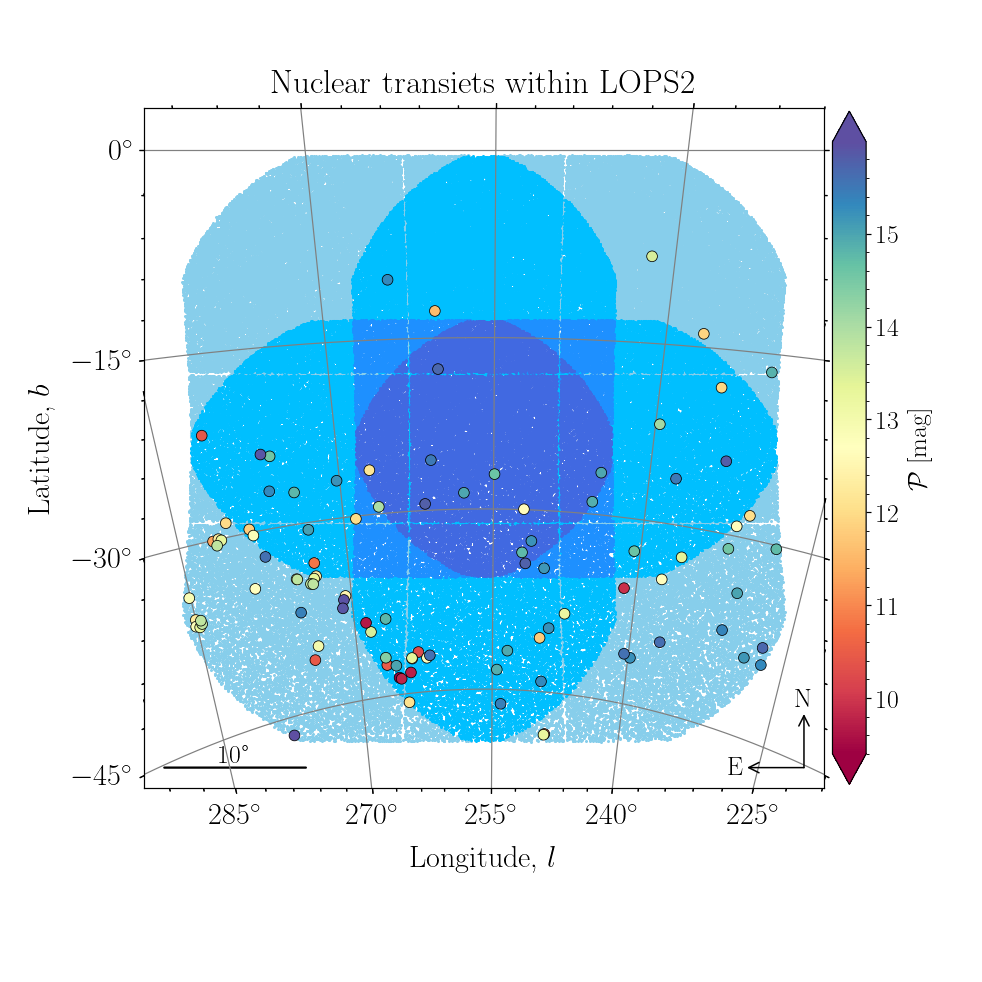

In [163]:
# Plot targets within LOPS2 foorptint
dx = df_gal.copy()
fig, ax = pt.plotPlatoFOV(
    'LOPS2', system='galactic', ncamStars=True, fovSize=30,
    raStars=dx.ra, decStars=dx.dec, c=dx.Vmag, 
    clabel=r'$\mathcal{P}$ [mag]', s=200, lw=0.5, ec='k',
    title='Nuclear transiets within LOPS2',
    figsize=(9,9)
);

---
## 5. SMBHB candidates
---

### CRTS candidates (Graham+2015) 

In [225]:
# Load Quaia catalogue
df_crts = pd.read_csv( ddir / 'smbhb_CRTS_Graham2015.csv')
df_crts.head()

,No.,Object Name,RA-s,Dec-s,RA,Dec,Object Type,cz (Velocity),Redshift (z),z flag,Reference,Note,Photometry,Position,Redshift,Diameter,Distances,Classification,Images,Spectra
0,1,LBQS 0009-0138,00h12m10.8907s,-01d22m07.630s,3.045378,-1.368786,QSO,599285.123542,1.999000,SUN,60,0,20,11,8,0,0,1,0,0
1,2,LBQS 0020+0058,00h23m03.1572s,+01d15m33.607s,5.763155,1.259335,QSO,218530.114750,0.728938,SUN,66,0,55,22,31,4,0,1,0,1
2,3,MRK 0504,17h01m07.7809s,+29d24m24.588s,255.282421,29.406830,G,10823.107319,0.036102,SUN,136,3,62,21,20,10,0,5,2,1
3,4,FBQS J0200+0125,02h00m03.9391s,+01d25m11.952s,30.016413,1.419987,QSO,350757.163868,1.170000,SUN,47,0,43,13,3,0,0,1,0,0
4,5,[HB89] 0246+009,02h49m28.8674s,+01d09m24.559s,42.370281,1.156822,QSO,285784.733346,0.953275,SLS,52,0,50,14,24,8,0,1,0,2


In [181]:
# # Fetch Gaia information for candidates
# dq_crts = sq.fetch_gaia_info(df_crts, NED=True)
# dq_crts.to_csv(ddir / 'smbhb_CRTS_Graham2015_gaia.csv')

In [226]:
# Fetch Gaia information for candidates
df_crts = pd.read_csv(ddir / 'smbhb_CRTS_Graham2015_gaia.csv')
df_crts.head()

,Unnamed: 0,source,source_gaia_dr3,ra,dec,l,b,Gmag,BP_RP,Ag,plx,plx_err,pm,pmra,pmra_error,pmdec,pmdec_error,ruwe,z
0,0,LBQS 0009-0138,2544750431910682240,3.045418,-1.368774,101.219051,-62.573954,17.388350,0.620436,0.0016,-0.003557,0.110065,0.149037,0.093500,0.148184,0.116059,0.089669,0.942214,1.999000
1,1,LBQS 0020+0058,2547022091653816064,5.763146,1.259344,108.266392,-60.801604,18.173792,0.361698,0.0009,0.039268,0.136403,0.247724,-0.125657,0.166791,-0.213489,0.148137,0.949413,0.728938
2,2,MRK 0504,1309563295515831808,255.282411,29.406828,51.079327,35.649002,16.658611,1.072939,NaN,-0.016493,0.050889,0.189918,-0.017558,0.052126,-0.189105,0.063688,1.096174,0.036102
3,3,FBQS J0200+0125,2508348178894931072,30.016400,1.420007,155.730776,-57.016039,17.903145,0.488579,0.0118,-0.118309,0.158830,0.323819,0.313600,0.180518,0.080706,0.124687,1.013237,1.170000
4,4,[HB89] 0246+009,2499165397082525568,42.370262,1.156853,172.831862,-49.921207,18.589943,0.390921,0.0014,-0.334021,0.195003,0.416445,-0.150080,0.207406,-0.388461,0.194389,1.005635,0.953275


<IPython.core.display.Javascript object>


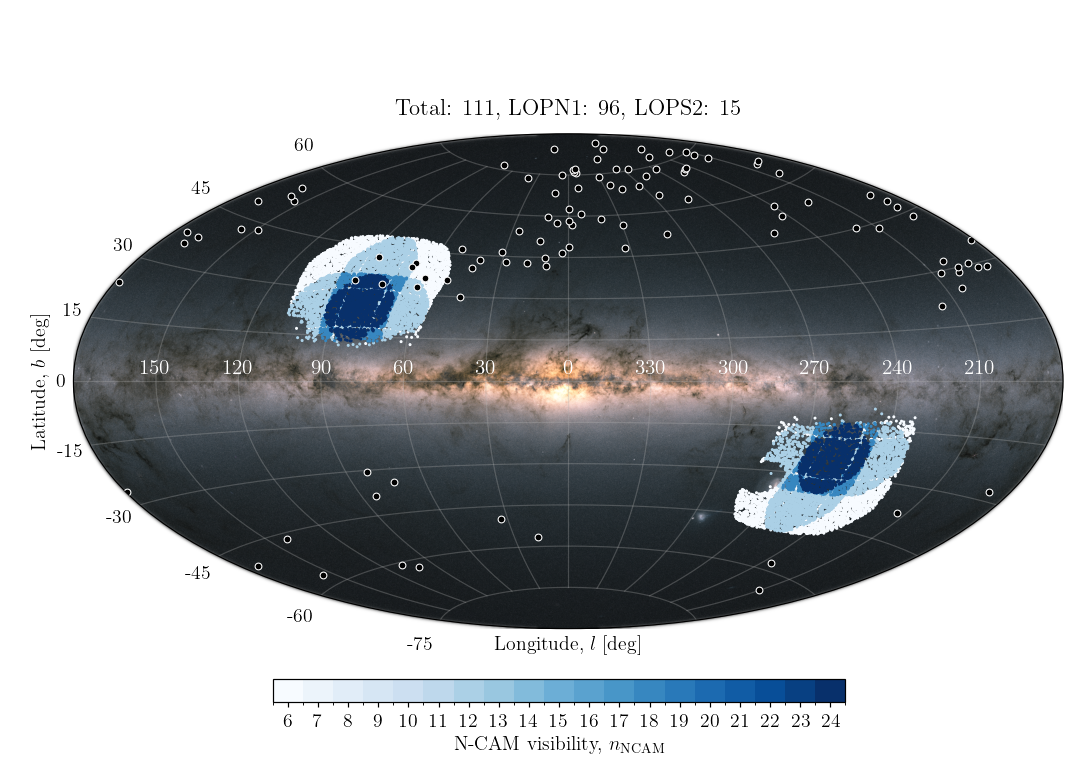

In [224]:
# Show matching sources in sky
fig, ax = pt.plot_aitoff(dt, df_crts)

In [203]:
# # Match to original catalogues
# dt_crts = dt[dt['source_gaia_dr3'].isin(dq_crts['source_gaia_dr3'])]
# dx_crts = dq_crts[dq_crts['source_gaia_dr3'].isin(dt['source_gaia_dr3'])]

# # Add missing target
# dx_crts = dx_crts.append(dq_crts.loc[41])
# dx_crts.source_gaia_dr3 = dx_crts.source_gaia_dr3.astype(int)
# dt_crts = dt_crts.append(dq_crts.loc[41])
# dt_crts.source_gaia_dr3 = dt_crts.source_gaia_dr3.astype(int)

# # Add columns and missing parameters
# dt_crts.iloc[1].z = dx_crts.iloc[1].z
# dt_crts.iloc[1].z = dx_crts.iloc[1].z

# # Sort after magnitude
# dx_crts = dx_crts.sort_values(by='Gmag')
# dt_crts = dt_crts.sort_values(by='Gmag')
# dt_crts

In [202]:
# # Plot candidates in sky
# fig, ax = pt.plot_aitoff(dt, df_crts, False, dt_crts)

In [168]:
# # Load raw catalogue
# df1_crts = pd.read_csv(ddir / 'smbhb_CRTS_Graham2015_FromCharisi.csv')

# # Change coordinates to deg
# for i in range(df1_crts.shape[0]):
#     dx = df1_crts.iloc[i]
#     coor = SkyCoord(ra=dx.ra, dec=dx.dec,unit=(u.hourangle, u.deg))
#     df1_crts.ra.iloc[i]  = coor.ra.deg
#     df1_crts.dec.iloc[i] = coor.dec.deg

# # Add Galactic coordinates
# gal_crts = SkyCoord(df_crts.ra, df_crts.dec, frame='icrs', unit=u.deg).galactic
# df_crts['l'] = gal_crts.l.deg
# df_crts['b'] = gal_crts.b.deg
# df_crts.head()

# # Add columns from
# df0_crts = df0_crts.sort_values(by='ra')
# df1_crts =df1_crts.sort_values(by='ra')

# # df_crts = dq_crts.copy()
# # df_crts['name']   = df1_crts.object
# # df_crts['logMbh'] = df1_crts.logmbh

### PTF candidates (Charisi+2016)

In [230]:
# # Load Quaia catalogue
# df_ptf = pd.read_csv( ddir / 'smbhb_PTF_Charisi2016.csv')

# # # Remove non-significant candidates
# df_ptf = df_ptf.sort_values(by='RA').reset_index(drop=True)
# num = np.array([11, 39, 5, 40, 3, 24, 25, 26, 7, 29, 31, 28, 32, 42, 34, 38, 50])
# for n in num: df_ptf = df_ptf[df_ptf['No.'] != n]
# df_ptf = df_ptf.reset_index(drop=True)
# df_ptf.head()

In [188]:
# # Fetch Gaia information for candidates
# dq_ptf = sq.fetch_gaia_info(df_ptf, NED=True)
# dq_ptf.reset_index(drop=True).to_csv(ddir / 'smbhb_PTF_Charisi2016_gaia.csv')

In [13]:
# Fetch Gaia information for candidates
df_ptf = pd.read_csv(ddir / 'smbhb_PTF_Charisi2016_gaia.csv')
df_pft = df_ptf.drop(df_ptf.columns[0], axis=1)

In [233]:
# Match to original catalogues
dt_ptf = dt[dt['source_gaia_dr3'].isin(dq_ptf['source_gaia_dr3'])]
dx_ptf = dq_ptf[dq_ptf['source_gaia_dr3'].isin(dt['source_gaia_dr3'])]
dt_ptf

,ncam,source_gaia_dr3,ra,dec,l,Pmag,b,Gmag,BP_RP,Ag,...,z,z_err,period,period_std,log_B_PR,log_B_PR_std,ncon,SPR,rOA,NSR
1892,6,1334992113248412800,259.072919,34.26482,57.710328,18.755137,33.599713,18.935167,0.564959,0.0028,...,1.135056,0.04845,NaN,NaN,NaN,NaN,7.0,0.000592,14.341099,26602.606945


In [7]:
# Show matching sources in sky
# fig, ax = pt.plot_aitoff(dt, df_ptf, False, dt_ptf, NED=False)

### PanSTARS-1 candidate (Liu+2019) 

In [236]:
# Query single target
df_pan = sq.simbadQuery('PSO J185.8689+46.9752')

# Add Galactic coordinates
gal_pan = SkyCoord(df_pan.ra, df_pan.dec, frame='icrs', unit=u.deg).galactic
df_pan['l'] = gal_pan.l.deg
df_pan['b'] = gal_pan.b.deg
df_pan

,dis,gaiaDR3,ra,dec,Gmag,BP_RP,plx,plxe,pmra,pmdec,ruwe,teff,logg,Pmag,l,b
0,0.0,1545324010421021952,185.868936,46.975219,20.405256,0.677952,-1.064516,0.73807,-0.085484,-0.057707,0.960642,NaN,NaN,20.195675,136.586706,69.404737


In [8]:
# Show matching sources in sky
# fig, ax = pt.plot_aitoff(dt, df_pan)

### Kepler candidate Spikey (Hu+2020)

In [238]:
df_spikey = sq.simbadQuery('KIC 011606854', radius=0.01)
df_spikey

,dis,gaiaDR3,ra,dec,Gmag,BP_RP,plx,plxe,pmra,pmdec,ruwe,teff,logg,Pmag
0,0.0,2132637943222806784,289.689915,49.632232,17.750565,0.348852,0.030644,0.077436,0.016816,0.033494,1.028128,7461.581055,4.3967,17.633261


In [239]:
dt_spikey = dt[dt['source_gaia_dr3'].isin(df_spikey['gaiaDR3'])]
dt_spikey

,ncam,source_gaia_dr3,ra,dec,l,Pmag,b,Gmag,BP_RP,Ag,...,z,z_err,period,period_std,log_B_PR,log_B_PR_std,ncon,SPR,rOA,NSR
5363,24,2132637943222806784,289.689915,49.632232,80.891221,17.63326,16.192104,17.750565,0.348852,0.0012,...,0.920141,0.080362,NaN,NaN,NaN,NaN,29.0,0.022962,11.761182,4569.139569


In [9]:
# Show matching sources in sky
# fig, ax = pt.plot_aitoff(dt, dt_spikey)

### ZTF candidates (Chen+2024) 

In [243]:
# # Load Quaia catalogue
# df_ztf = pd.read_csv(ddir / 'smbhb_ZTF_Chen2024.csv')
# df_ztf = df_ztf[df_ztf['Object Type'] == 'QSO']
# df_ztf

In [208]:
# Missing magnitude hence fetch Gaia info
# dq_ztf = sq.fetch_gaia_info(df_ztf, NED=True)
# dq_ztf.to_csv(ddir / 'smbhb_ZTF_Chen2024_gaia.csv')

In [244]:
# Load Gaia query
df_ztf = pd.read_csv(ddir / 'smbhb_ZTF_Chen2024_gaia.csv')
df_ztf

,Unnamed: 0,source,source_gaia_dr3,ra,dec,l,b,Gmag,BP_RP,Ag,plx,plx_err,pm,pmra,pmra_error,pmdec,pmdec_error,ruwe,z
0,0,LBQS 0019-0000,2546805792804731136,5.541486,0.274810,107.342593,-61.707751,18.180544,0.445017,0.0010,0.192554,0.143812,0.321096,0.283561,0.172395,-0.150652,0.120547,0.951310,0.574826
1,1,WISEA J004039.78+150321.2,2779749906813051136,10.165804,15.055890,119.062791,-47.734898,18.291025,0.766127,0.0050,-0.044766,0.158560,0.192882,0.036610,0.170271,-0.189375,0.117502,1.006960,0.883881
2,2,WISEA J003718.87+143222.0,2779625215322558080,9.328609,14.539433,117.801429,-48.191574,18.659313,0.575275,0.0038,-0.028162,0.207067,0.083738,0.044231,0.248322,-0.071103,0.180571,1.004965,0.798376


In [10]:
# Show matching sources in sky
# fig, ax = pt.plot_aitoff(dt, df_ztf)

### AIFU candidates (Horlaville+2025)

In [246]:
# Load data
df_aifu = pd.read_csv(ddir / 'smbhb_AIFU_Horlaville2025.csv')

# Add Galactic coordinates
gal_aifu = SkyCoord(df_aifu.ra, df_aifu.dec, frame='icrs', unit=u.deg).galactic
df_aifu['l'] = gal_aifu.l.deg
df_aifu['b'] = gal_aifu.b.deg
df_aifu.head()

,Name,source_gaia_dr3,ra,dec,Gmag,Rank,D_Mpc,Survey,log_M_bh,log_h_0,LDA,h_norm,LDA_norm,Score,Profile,l,b
0,NGC4073,3891772263220977408,181.112749,1.896003,20.091410,1,91.5,MASSIVE,10.25,-13.04,4.08,0.98,0.99,0.99,C,276.908084,62.369710
1,NGC1016,2502292927842652800,39.581540,2.119301,20.193127,2,95.2,MASSIVE,10.25,-13.06,3.86,0.98,0.97,0.97,C,168.539989,-51.034946
2,NGC2832,0,139.945221,33.749742,NaN,3,105.2,MASSIVE,10.30,-13.02,3.62,0.99,0.94,0.97,C,191.092816,44.391434
3,NGC4486,3907709439453756032,187.705927,12.391125,16.838953,4,17.2,ATLAS3D,9.72,-13.20,4.03,0.93,0.98,0.96,C,283.777739,74.491155
4,NGC1060,0,40.812688,32.425011,NaN,5,67.4,MASSIVE,10.00,-13.32,4.21,0.90,1.00,0.95,NaN,148.767244,-24.777228


In [11]:
# # Plot all candidates
# dx = df_aifu
# fig, ax = pt.drawStarsInSkyAitoff(
#     dx.ra, dx.dec, column=dx.Gmag, 
#     cbarLabel=r'Gaia magnitude, $G$', 
#     title=f'Total: {dx.shape[0]}',
#     color='orange', fs=15, ms=5,
#     figsize=(10,7)
# );

In [248]:
# Check overlapping candidates
dt_aifu = dt[dt['source_gaia_dr3'].isin(df_aifu['source_gaia_dr3'])]
dx_aifu = df_aifu[df_aifu['source_gaia_dr3'].isin(dt['source_gaia_dr3'])]
dt_aifu

,ncam,source_gaia_dr3,ra,dec,l,Pmag,b,Gmag,BP_RP,Ag,...,z,z_err,period,period_std,log_B_PR,log_B_PR_std,ncon,SPR,rOA,NSR


In [249]:
# No overlapping candidates but the following sources are within the LOPN1
dex_aifu = np.array([48, 51, 82, 86, 89, 92, 95, 96, 97, 99, 111, 136, 173, 182, 194, 219, 242])
dx_aifu = df_aifu.loc[dex_aifu].sort_values(by='Gmag')

# Make cuts and alter data frame
dt_aifu = dx_aifu[(dx_aifu.Gmag < 19) & (dx_aifu.LDA > 3)]
dt_aifu = dt_aifu.reset_index(drop=True)
dt_aifu

,Name,source_gaia_dr3,ra,dec,Gmag,Rank,D_Mpc,Survey,log_M_bh,log_h_0,LDA,h_norm,LDA_norm,Score,Profile,l,b
0,NGC6703,2118960907628642688,281.828404,45.550632,17.083054,83,25.9,ATLAS3D,8.48,-15.45,3.91,0.25,0.97,0.71,P,74.893839,19.677648
1,NGC6515,1364561721838534272,269.354973,50.728120,18.140308,98,106.2,CALIFA,8.84,-15.46,3.37,0.25,0.92,0.67,NaN,78.213626,28.983514
2,NGC6411,1435958685478118400,263.886853,60.813399,18.607180,100,61.3,CALIFA,8.65,-15.53,3.24,0.23,0.91,0.66,NaN,89.730686,32.628741


In [251]:
# # Show candidates in LOPN1 
# dx = dt_aifu.copy()
# fig, ax = pt.plotPlatoFOV(
#     'LOPN1', system='galactic',
#     ncamStars=True, ncamMap='PLATO-CS', showGalactic=False,
#     raStars=dx.ra, decStars=dx.dec, c=dx.Gmag, s=500, lw=1,
#     clabel=r'$\mathcal{P}$ [mag]', 
#     figsize=(9,9)
# );

### GASP candidates (Huijse+2026)

In [314]:
# Load GASP catalogue
df_gasp = pd.read_csv(ddir / 'smbhb_GASP_Huijse2026.csv')

# Add Galactic coordinates
gal = SkyCoord(df_gasp.ra, df_gasp.dec, frame='icrs', unit=u.deg).galactic
df_gasp['l'] = gal.l.deg
df_gasp['b'] = gal.b.deg
df_gasp.head()

,gaia_dr3_id,log_bf_PR,log_bf_PR_std,period,period_std,ra,dec,bp_rp,mean_mag_g_fov,quaia_unwise_id,...,CatNorth_PS1_id,AllWISE,AllWISE_R90_id,AllWISE_C75_id,Milliquas_v65_id,SDSS_DR14Q_id,LQAC_v5,Gaia_unWISE_id,l,b
0,2355222626225792,-1.508667,-2.855496,515.780467,25.322481,47.452499,3.154205,0.515883,19.678646,0468p030o0013998,...,1.117805e+17,J030948.60+030915.0,J030948.60+030915.0,J030948.60+030915.0,WISEA J030948.60+030915.0,NaN,NaN,0468p030o0013998,176.152214,-44.946271
1,2525131532946560,2.379494,0.771844,440.845796,20.916907,48.556532,3.952636,0.699678,19.647911,0486p045o0002890,...,1.127405e+17,J031413.56+035709.4,J031413.56+035709.4,J031413.56+035709.4,SDSS J031413.56+035709.4,NaN,NaN,0486p045o0002890,176.429483,-43.600065
2,7627415241299200,0.740170,-1.285753,169.373403,1.834795,45.664462,6.947335,0.743160,19.997242,0457p075o0002490,...,1.163305e+17,J030239.47+065650.4,J030239.47+065650.4,J030239.47+065650.4,SDSS J030239.47+065650.4,NaN,NaN,0457p075o0002490,170.705676,-43.425082
3,8314648663843456,2.501854,0.987029,539.604663,10.384097,43.877653,7.432423,0.647360,16.272747,0442p075o0010435,...,1.169104e+17,J025530.63+072556.7,J025530.63+072556.7,J025530.63+072556.7,RX J02555+0725,NaN,LQAC_043+007_001,0442p075o0010435,168.404355,-44.213207
4,8531419957948672,-0.034764,-2.145793,503.263610,32.593152,44.764676,7.854109,0.969009,19.564423,0442p075o0017138,...,1.174204e+17,J025903.52+075114.7,J025903.52+075114.7,J025903.52+075114.7,WISEA J025903.52+075114.7,NaN,NaN,0442p075o0017138,168.960902,-43.324841


In [12]:
# # Plot all candidates
# dx = df_gasp
# fig, ax = pt.drawStarsInSkyAitoff(
#     dx.ra, dx.dec, column=dx.mean_mag_g_fov, 
#     cbarLabel=r'Gaia magnitude, $G$', 
#     title=f'Total: {dx.shape[0]}',
#     color='orange', fs=15,
#     figsize=(10,7)
# );

In [316]:
# Match to original catalogues to find targets within LOPs
dx_gasp = df[df['source_gaia_dr3'].isin(df_gasp['gaia_dr3_id'])].sort_values(by=['source_gaia_dr3'])
dt_gasp = df_gasp[df_gasp['gaia_dr3_id'].isin(df['source_gaia_dr3'])].sort_values(by=['gaia_dr3_id'])

# Sperate LOPS2 and LOPN1
ds_gasp = dt_gasp[dt_gasp.b < 0]
dn_gasp = dt_gasp[dt_gasp.b > 0]

In [6]:
# # Plot candidates within LOPs
# fig, ax = pt.drawStarsInSkyAitoff(
#     dt_gasp.ra, dt_gasp.dec, 
#     column=dt_gasp.mean_mag_g_fov, 
#     cbarLabel=r'Gaia magnitude, $G$',
#     title=(f'Total: {dt_gasp.shape[0]}, ' + 
#            f'LOPN1: {dn_gasp.shape[0]}, ' + 
#            f'LOPS2: {ds_gasp.shape[0]}'),
#    fs=15, figsize=(10,7));

In [318]:
# Check number of sources available
ds0_gasp = ds_gasp[(ds_gasp.log_bf_PR > -7) & (ds_gasp.mean_mag_g_fov < 17.5)]
dn0_gasp = dn_gasp[(dn_gasp.log_bf_PR > -7) & (dn_gasp.mean_mag_g_fov < 17.5)]

# Cross-match with LOPS2 sources
ds0_gasp['gaia_dr3_id'] = [f'Gaia DR3 {i}' for i in ds0_gasp.gaia_dr3_id]
ds1_gasp = dc[dc['gaiaDR3'].isin(ds0_gasp['gaia_dr3_id'])].sort_values(by=['Pmag']).reset_index(drop=True)
ds1_gasp['ref'] = 'gasp'

In [319]:
ds1_gasp

,PIC,gaiaDR3,ra,dec,Gmag,Pmag,PBmag,PRmag,ref
0,2651105000077,Gaia DR3 4814737129992758912,70.322244,-43.229302,16.800446,16.684712,16.768487,16.573950,gasp
1,2630958000012,Gaia DR3 4842045803371034368,60.593506,-42.351989,17.233250,17.067952,17.198428,16.903103,gasp
2,2970216000134,Gaia DR3 5477972503895989376,94.827251,-62.669087,17.303650,17.115042,17.271468,16.922470,gasp
3,2981781000025,Gaia DR3 4675515485918487680,68.207007,-63.661641,17.373468,17.207603,17.338887,17.041943,gasp


<IPython.core.display.Javascript object>


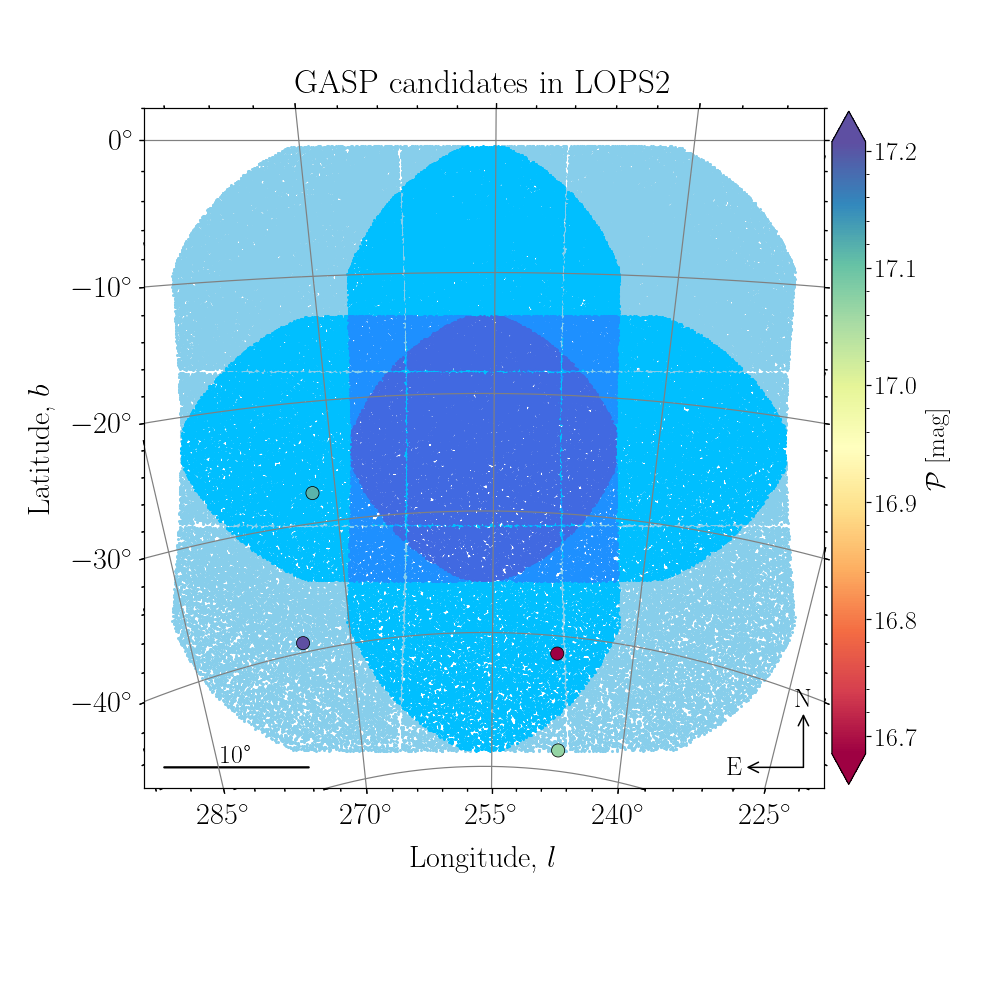

In [310]:
# Plot targets within LOPS2
dx = ds_gasp.copy()
fig, ax = pt.plotPlatoFOV(
    'LOPS2', system='galactic', ncamStars=True,
    raStars=dx.ra, decStars=dx.dec, c=dx.Pmag, 
    clabel=r'$\mathcal{P}$ [mag]', s=300, lw=0.5, ec='k',
    title='GASP candidates in LOPS2',
    figsize=(9,9)
);

---
## Proposal CfP check and plots
---

In [693]:
# Make a general sample data frame
dt = pd.concat([ds_gal, ds_PictorA, ds_nuclear, ds1_gasp])

### Plot targets in the LOPS2 footprint

<IPython.core.display.Javascript object>


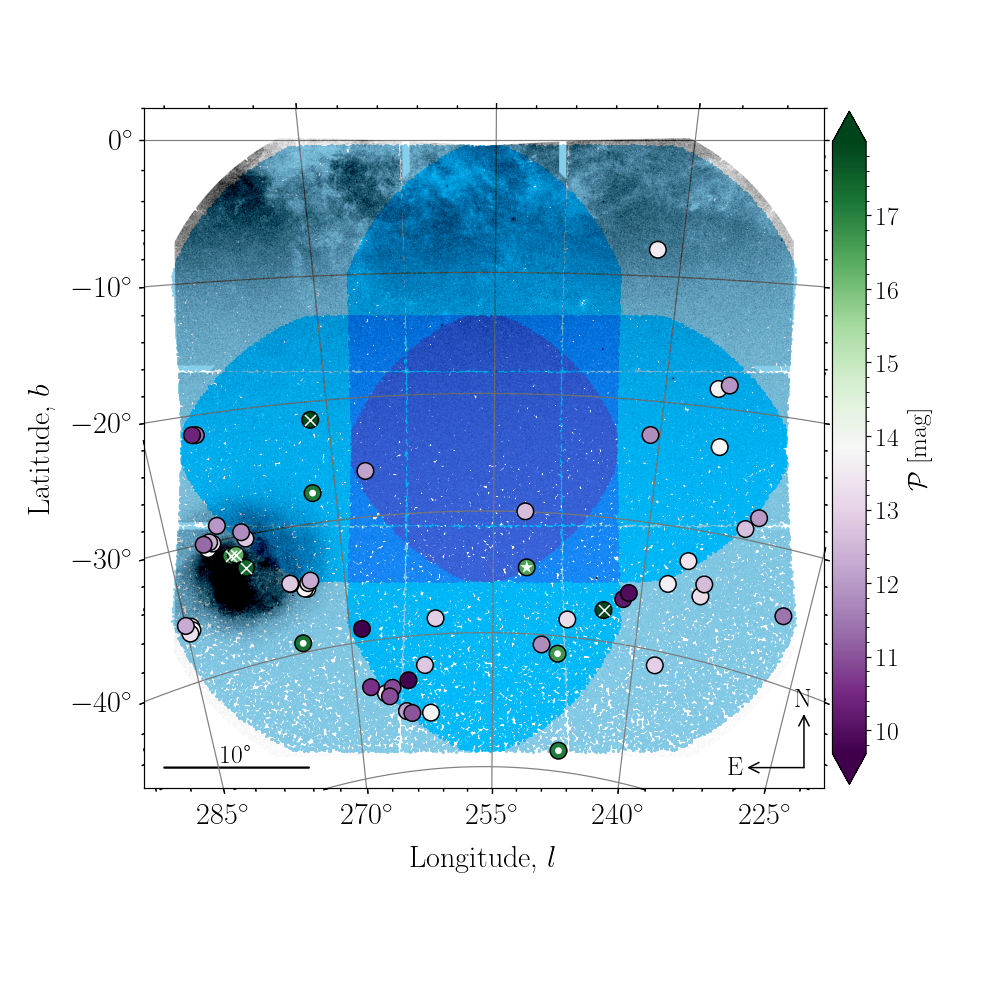

In [773]:
s, lw = 160, 2
# Plot catalogue within LOPS2 foorptint
dx = dt.sort_values(by='Pmag', ascending=False)
fig, ax = pt.plotPlatoFOV(
    'LOPS2', system='galactic', ncamStars=True, showGalactic=True,
    raStars=dx.ra, decStars=dx.dec, c=dx.Pmag, s=s*3, lw=lw-1, ec='k',
    clabel=r'$\mathcal{P}$ [mag]', cmap='PRGn', figsize=(9,9)
)
# Plot frequent flaring sources
dx = dt[dt.ref == 'PictorA']
gal = SkyCoord(dx.ra*u.deg, dx.dec*u.deg, frame='icrs', unit='deg').galactic
ax.scatter(gal.l.deg, gal.b.deg, transform=ax.get_transform('world'),
           marker='*', facecolors='w', edgecolors='none', s=s/2, lw=lw, zorder=10)

# Plot SMBHB candidates
dx = dt[dt.ref == 'gasp']
gal = SkyCoord(dx.ra*u.deg, dx.dec*u.deg, frame='icrs', unit='deg').galactic
ax.scatter(gal.l.deg, gal.b.deg, transform=ax.get_transform('world'),
           marker='.', facecolors='w', edgecolors='none', s=s/2, lw=lw, zorder=10)

# Plot frequent flaring sources
dx = dt[dt.ref == 'nuclear']
gal = SkyCoord(dx.ra*u.deg, dx.dec*u.deg, frame='icrs', unit='deg').galactic
ax.scatter(gal.l.deg, gal.b.deg, transform=ax.get_transform('world'),
           marker='x', facecolors='w', edgecolors='none', s=s/3, lw=lw/2, zorder=10)

# Save figure
fig.savefig(fdir / 'plot_transients_sky.png', bbox_inches='tight', dpi=300)

### Plot targets in NSR vs. Mag

In [740]:
# Bright NSR estimates from Jannsen+2025
df_nsr_bright = pd.read_feather('/lhome/nicholas/software/workdir/mocka/simulations/nsr/nsr_per_star_BOL.ftr')
df_nsr_bright = df_nsr_bright.drop(columns=['index', 'ID','rOA'])
 # Account for "as required" -> "as expected" update in Jannsen+2026
df_nsr_bright.NSR /= 1.1

# Faint NSR estimates from Jannse+2026
df = df.sort_values(by=['ncam', 'Pmag']).reset_index(drop=True)
df_nsr_faint = pd.DataFrame({
    'mag': df.Pmag,
    'ncon': df.ncon,
    'SPR': df.SPR,
    'ncam': df.ncam,
    'NSR': df.NSR
})
df_nsr = pd.concat([df_nsr_bright, df_nsr_faint])

<IPython.core.display.Javascript object>


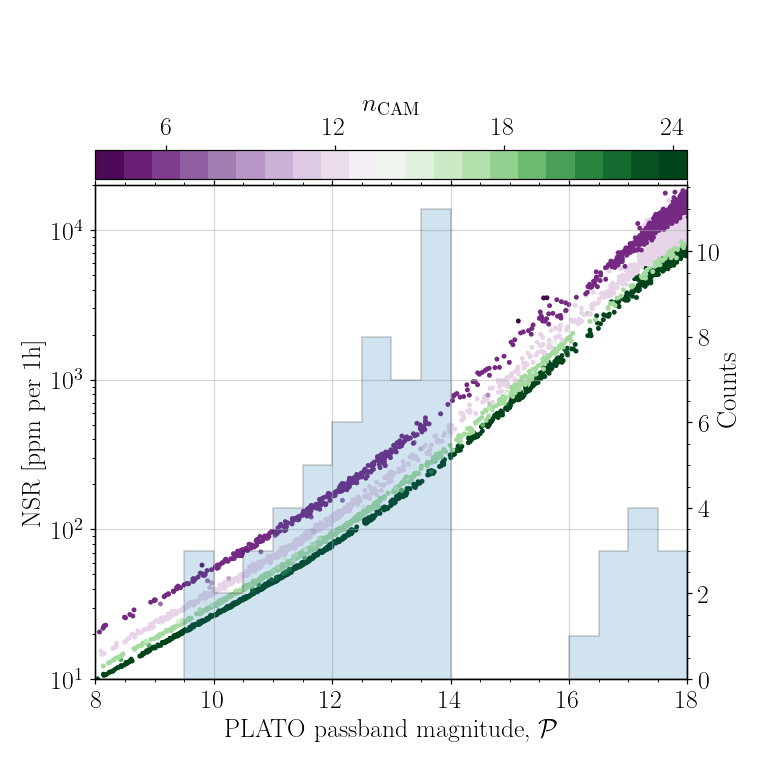

In [777]:
# Plot mission level NSR for LOPS2
cmap = 'PRGn'
col = 'ncam'
lim = 0.01
dx = df_nsr.copy().sort_values(by=[col], ascending=False)
dx = dx[dx.SPR < lim]

fig, ax = plt.subplots(1, 1, figsize=(7,7))

# NSR vs. mag plot
im = ax.scatter(dx.mag, dx.NSR, s=5, alpha=1, zorder=1, c=dx[col], cmap=cmap)
cbins = np.arange(dx[col].min(), dx[col].max()+2, 1)
ticks = np.array([1, 6, 12, 18, 24]) + 0.5 
norm  = pt.discretizeColorbar(cbins=cbins, cmap=cmap)
cb = plt.colorbar(im, pad=0.01, spacing='proportional', location='top',
                  ticks=ticks, boundaries=cbins, format='%1i')
cb.set_label(r'$n_{\rm CAM}$')
cb.minorticks_off()
ax.set_xlabel('PLATO passband magnitude, $\mathcal{P}$')
ax.set_ylabel('NSR [ppm per 1h]')
ax.set_yscale('log')
ax.grid(alpha=0.5)
ax.set_xlim(8, 18)
ax.set_ylim(1e1, 2e4)

# Plot light curve
ax2 = ax.twinx().twiny()
ax2.hist(dt.Pmag, bins=20, range=(8,18), histtype='stepfilled', ec='k', lw=1, alpha=0.2, zorder=0)
ax2.text(18.5, 6, 'Counts', c='k', fontsize=18, rotation=90)
ax2.set_xlim(8, 18)
ax2.set_xticks([])

# Save figure
fig.savefig(fdir / 'plot_transients_nsr.png', bbox_inches='tight', dpi=300)